## Tutorial 1: Motor and naturalistic behavior - from tracking data to latent dynamics

In this tutorial we analyze the swimming behavior of larval zebrafish recorded by Marques et al. 2018, *Current Biology* (paper: DOI: 10.1016/j.cub.2017.12.002, data: https://data.mendeley.com/datasets/r9vn7x287r/1). Marques et al. tracked x,y positions of 9 keypoints along the tail of freely swimming larval zebrafish at 700 Hz. They segmented continuous time series into discrete swim periods (called "bouts"), between which the fish remains still.

For each detected bout, the data structure contains a time series of 8 inter-segment angles (angle between adjacent tracked points). For each bout, they exctracted 73 kinematic features (such as the velocity, amplitude and duration of a tail flip). They performed unsupervised clustering on these features, revealing 13 distinct behavioral bout types.

#### Part 0 – Pre-classified bout data
- linear dimensionality reduction
- trajectories in latent space
- linear dynamical systems (LDS)

#### Part 1 – Continuous time series
- time-varying dynamics
- hidden Markov models (HMM)
- switching LDS (sLDS)

## 0. Setup

In [1]:
# Uncomment to install the packages you need
!pip install cython
!pip install git+https://github.com/lindermanlab/ssm  # for sLDS in Part 2

  Cloning https://github.com/lindermanlab/ssm to /tmp/pip-req-build-ijqhbapi
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm /tmp/pip-req-build-ijqhbapi
  Resolved https://github.com/lindermanlab/ssm to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done
  Created wheel for ssm: filename=ssm-0.0.1-cp312-cp312-linux_x86_64.whl size=614354 sha256=42cc48c0d6f6db57c99310807ec11c88f7b1cde10a83cda10a36f267c7510d1c
  Stored in directory: /tmp/pip-ephem-wheel-cache-msgamsvw/wheels/1d/0f/c0/c053f3b0ad952bec48922f3de51ab1a50a18514fc87533aedd
Successfully built ssm


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import ssm

rng = np.random.default_rng(42)


---
## Part 0: Load data and visualize

### 0.1  Load the data

Place `zebrafish_data.npz` in the `data/` subfolder next to this notebook and run the cell below.

The file contains pre-processed data from Marques et al. 2018 (*Current Biology*):

| Array | Shape | Description |
|---|---|---|
| `bout_angles` | `(n_bouts, 150, 8)` | Tail-segment angles (rad); zero-padded to 150 frames |
| `bout_labels` | `(n_bouts,)` | Bout type 1–13 |
| `bout_xy` | `(n_bouts, 150, 2)` | Fish x/y position; zero-padded to 150 frames |
| `cont_seqs` | list of `(T_i, 8)` | Raw `BoutContinuousData` per fish — consecutive tracked frames |
| `cont_labels_list` | list of `(T_i,)` | Frame-level bout-type label (1–13) |


In [3]:
import urllib.request
import io

url = 'https://raw.githubusercontent.com/bambschool/BAMB2026/main/Module%205/data/zebrafish_data.npz'
with urllib.request.urlopen(url) as response:
    data = np.load(io.BytesIO(response.read()))

bout_angles      = data['bout_angles']    # (n_bouts, 100, 8)
bout_labels      = data['bout_labels']    # (n_bouts,)
bout_xy          = data['bout_xy']        # (n_bouts, 100, 2)

offsets          = data['cont_offsets']
cont_seqs        = [data['cont_angles'][offsets[i]:offsets[i+1]]
                    for i in range(len(offsets) - 1)]
cont_labels_list = [data['cont_labels'][offsets[i]:offsets[i+1]]
                    for i in range(len(offsets) - 1)]

n_bouts, T, n_angles = bout_angles.shape
fps = 700
print(f'Bouts: {n_bouts}  |  shape {bout_angles.shape}  |  types {np.unique(bout_labels)}')
print(f'Continuous: {len(cont_seqs)} fish  |  {sum(len(s) for s in cont_seqs):,} frames at {fps} Hz')


Bouts: 1626  |  shape (1626, 150, 8)  |  types [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
Continuous: 14 fish  |  105,978 frames at 700 Hz


In [4]:
# Desired display order (Marques 2018 original labels → new positions 1-13)
desired_order = [11, 7, 9, 1, 2, 3, 5, 13, 8, 12, 4, 6, 10]
bout_type_names = {i+1: name for i, name in enumerate([
    'Approach Swim', 'Slow Swim 1', 'Slow Swim 2',
    'Short Latency Capture Swim', 'Long Latency Capture Swim', 'Burst Swim',
    'J-turn', 'High Angle Turn', 'Routine Turn',
    'Spot Avoidance Turn', 'O-bend',
    'Short Latency C Escape Swim', 'Long Latency C Escape Swim',
])}

old_to_new = np.zeros(14, dtype=int)   # 0 → 0 (non-bout frames stay 0)
for new_idx, old_lbl in enumerate(desired_order, start=1):
    old_to_new[old_lbl] = new_idx

bout_labels      = old_to_new[bout_labels]
cont_labels_list = [old_to_new[cl] for cl in cont_labels_list]

# For turning bouts (new labels 7-13), canonicalize direction:
# flip angles of bouts where active frames are majoritarily negative
flip_types = set(range(7, 14))
n_flipped = 0
for i in range(len(bout_angles)):
    if bout_labels[i] not in flip_types:
        continue
    active = np.any(bout_angles[i] != 0, axis=1)
    if active.sum() == 0:
        continue
    if bout_angles[i][active].mean() < 0:
        bout_angles[i] = -bout_angles[i]
        n_flipped += 1
print(f'Flipped {n_flipped} / {(np.isin(bout_labels, list(flip_types))).sum()} turning bouts')


Flipped 591 / 1162 turning bouts


### 0.2  Visualizing body posture during a bout

First, we will visualize example x,y swim trajectories for each bout type.

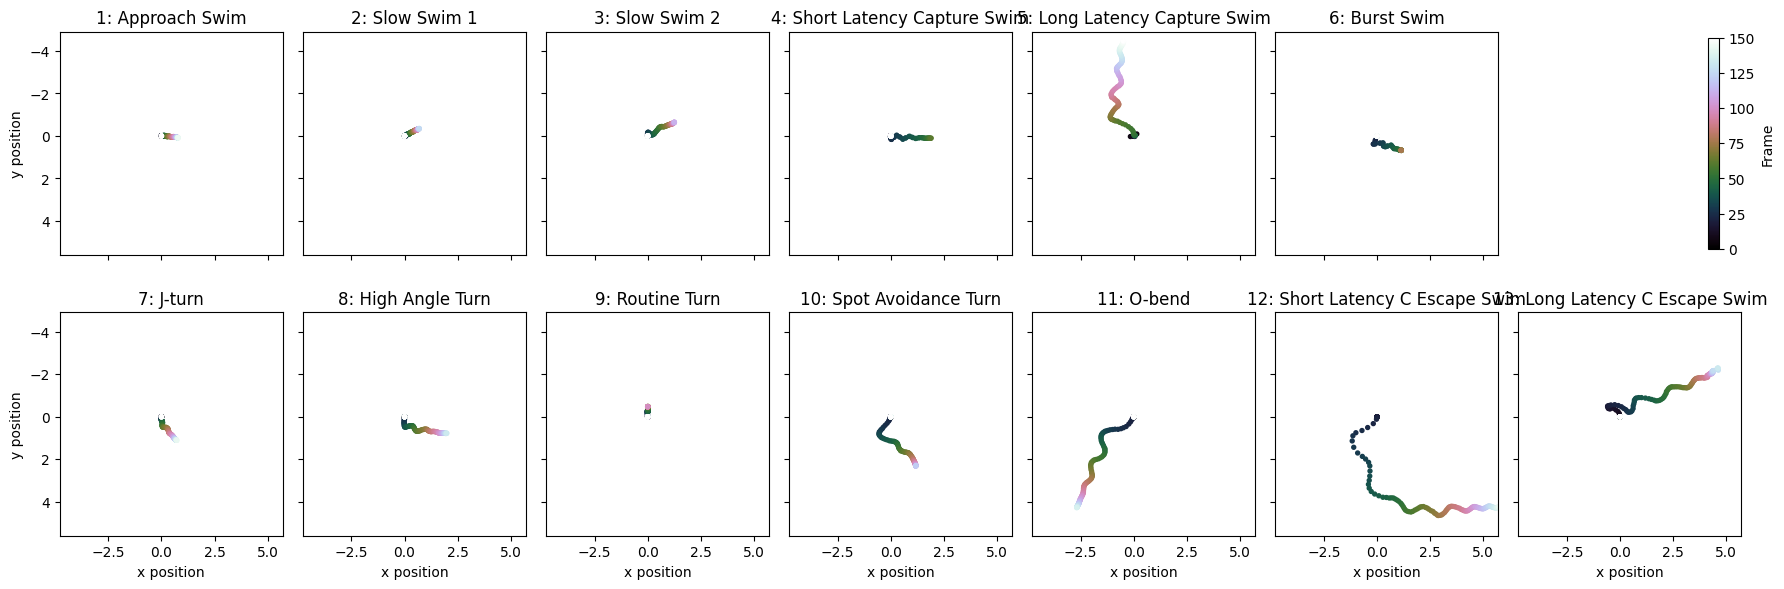

In [5]:
cmap_t = plt.cm.cubehelix
t_vals = np.linspace(0, 1, T)

fig, axes = plt.subplots(2, 7, figsize=(18, 6), sharex=True, sharey=True)

positions = [(0, j) for j in range(6)] + [(1, j) for j in range(7)]
all_xy = []
for (r, c), syl in zip(positions, range(1, 14)):
    ax  = axes[r, c]
    idx = np.where(bout_labels == syl)[0][2]
    xy  = bout_xy[idx]  # (T, 2)
    all_xy.append(xy)
    ax.scatter(xy[:, 0], xy[:, 1], c=t_vals, cmap=cmap_t, s=8, rasterized=True)
    ax.set_title(f'{syl}: {bout_type_names[syl]}')
    ax.set_aspect('equal')

all_xy = np.concatenate(all_xy)
cx, cy = all_xy[:, 0].mean(), all_xy[:, 1].mean()
half = max(all_xy[:, 0].max() - all_xy[:, 0].min(), all_xy[:, 1].max() - all_xy[:, 1].min()) / 2 * 1.15
axes.flat[0].set_xlim(cx - half, cx + half)
axes.flat[0].set_ylim(cy - half, cy + half)
axes.flat[0].invert_yaxis()

for ax in axes[:, 0]:
    ax.set_ylabel('y position')
for ax in axes[-1, :]:
    ax.set_xlabel('x position')

sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, T))
axes[0, 6].set_visible(True)
fig.colorbar(sm, ax=axes[0, 6], label='Frame', shrink=0.8)
axes[0, 6].axis('off')

fig.tight_layout()
# fig.savefig('fig_xy_trajectories.pdf', bbox_inches='tight')


### 0.3  Visualizing realigned and centered body posture during a bout

Next, we will reconstruct the body segments in centered and realigned x,y space.

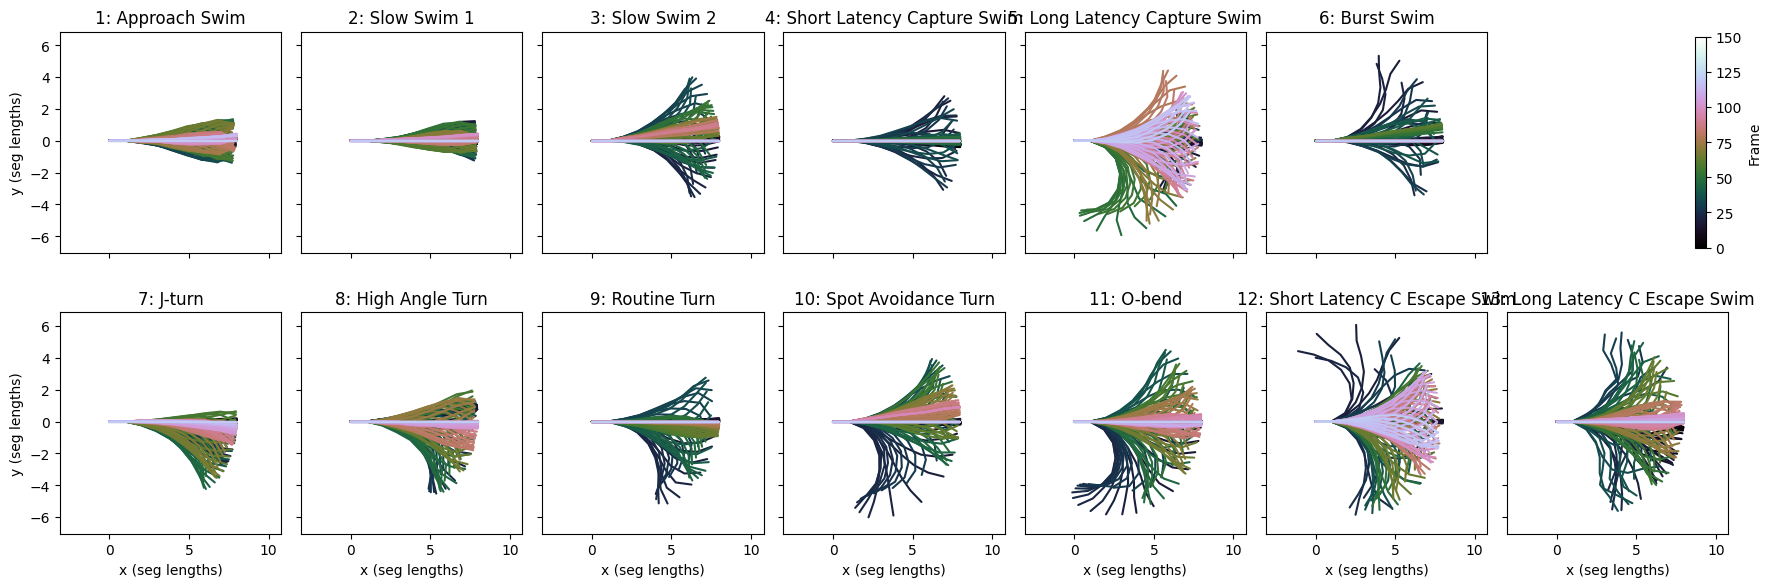

In [6]:
def reconstruct_body(angles):
    pos = np.zeros((len(angles) + 1, 2))
    for k, a in enumerate(angles):
        pos[k + 1] = pos[k] + [np.sin(a), np.cos(a)]
    # rotate so first segment points right; tail free to curve
    d = pos[1] - pos[0]
    phi = np.arctan2(d[1], d[0])
    ct, st = np.cos(phi), np.sin(phi)
    return (pos - pos[0]) @ np.array([[ct, -st], [st, ct]])

cmap = plt.cm.cubehelix
frame_colors = cmap(np.linspace(0, 0.8, T))

fig, axes = plt.subplots(2, 7, figsize=(18, 6), sharex=True, sharey=True)

positions = [(0, j) for j in range(6)] + [(1, j) for j in range(7)]
all_xy = []
for (r, c), syl in zip(positions, range(1, 14)):
    ax = axes[r, c]
    idx = np.where(bout_labels == syl)[0][2]
    for t, color in enumerate(frame_colors):
        xy = reconstruct_body(bout_angles[idx, t])
        all_xy.append(xy)
        ax.plot(*xy.T, color=color, solid_capstyle='round')
    ax.set_title(f'{syl}: {bout_type_names[syl]}')
    ax.set_aspect('equal')

all_xy = np.concatenate(all_xy)
cx, cy = all_xy[:, 0].mean(), all_xy[:, 1].mean()
half = max(all_xy[:, 0].max() - all_xy[:, 0].min(), all_xy[:, 1].max() - all_xy[:, 1].min()) / 2 * 1.15
axes.flat[0].set_xlim(cx - half, cx + half)
axes.flat[0].set_ylim(cy - half, cy + half)

for ax in axes[:, 0]:
    ax.set_ylabel('y (seg lengths)')
for ax in axes[-1, :]:
    ax.set_xlabel('x (seg lengths)')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, T))
axes[0, 6].set_visible(True)
fig.colorbar(sm, ax=axes[0, 6], label='Frame', shrink=0.8)
axes[0, 6].axis('off')

fig.tight_layout()
# fig.savefig('fig_body_shapes.pdf', bbox_inches='tight')


### 0.4  Visualizing tail angle timeseries

Finally, we will plot the signal that we will be modeling, the 8 different tail segment angles as time series. Plotting them together shows the wave that propagates down the tail during a swim stroke.

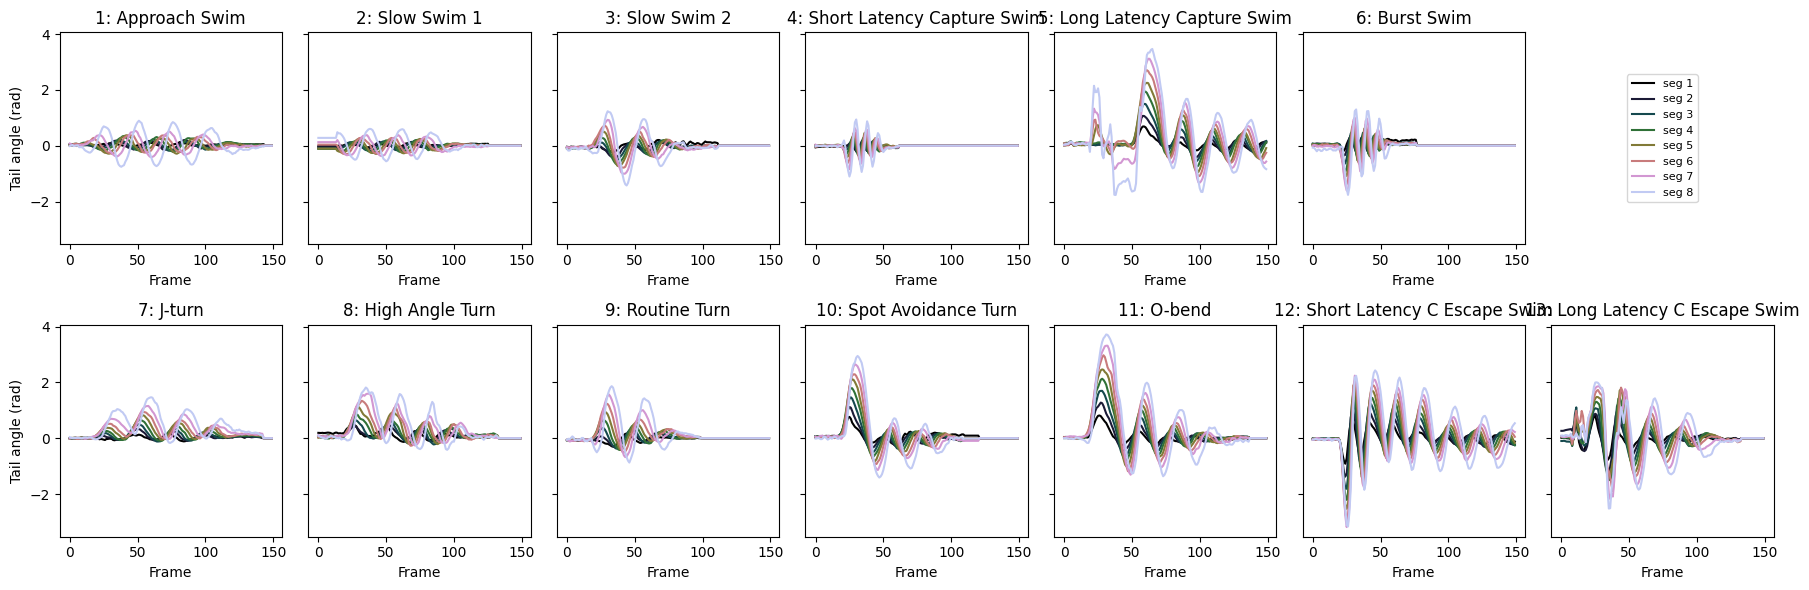

In [7]:
bout_colors = plt.cm.Set3(np.linspace(0, 1, 13))
angle_colors = plt.cm.cubehelix(np.linspace(0, .8, n_angles))

fig, axes = plt.subplots(2, 7, figsize=(18, 6), sharey=True)

positions = [(0, j) for j in range(6)] + [(1, j) for j in range(7)]
for (r, c), syl in zip(positions, range(1, 14)):
    ax  = axes[r, c]
    idx = np.where(bout_labels == syl)[0][2]
    for j in range(n_angles):
        ax.plot(bout_angles[idx, :, j], color=angle_colors[j])
    ax.set_title(f'{syl}: {bout_type_names[syl]}')
    ax.set_xlabel('Frame')

for ax in axes[:, 0]:
    ax.set_ylabel('Tail angle (rad)')

handles = [plt.Line2D([0], [0], color=angle_colors[j], label=f'seg {j+1}')
           for j in range(n_angles)]
axes[0, 6].set_visible(True)
axes[0, 6].legend(handles=handles, fontsize=8, loc='center')
axes[0, 6].axis('off')

fig.tight_layout()
# fig.savefig('fig_bout_timeseries.pdf', bbox_inches='tight')


---
## Part 1: Dimensionality reduction

### 1.1  From high-D to low-D: PCA

At each time frame within a bout we observe a vector $\mathbf{x}_t \in \mathbb{R}^{d}$ of $d$ tail angles ($d=8$). Across all frames of all bouts we get a large data matrix $X \in \mathbb{R}^{N \times d}$ (where $N = n_{\text{bouts}} \times T$).

**Linear dimensionality reduction.** We want to approximate our angular time series data as a weighted sum of $k \ll d$ fixed spatial patterns, while explaining as much variance in original data as possible:

$$\mathbf{x}_t \approx \tilde{U}\mathbf{z}_t = \sum_{j=1}^k z_j(t)\,\mathbf{u}_j$$

where $\tilde{U} = [\mathbf{u}_1 \cdots \mathbf{u}_k] \in \mathbb{R}^{d \times k}$ is the **loading or weight matrix** (columns = spatial patterns) and $\mathbf{z}_t \in \mathbb{R}^k$ are the **latent variables** (how much of each pattern is present at time $t$). Given $\tilde{U}$, the best latents are the projections $\mathbf{z}_t = \tilde{U}^\top \mathbf{x}_t$, and the reconstruction error is $\|\mathbf{x}_t - \tilde{U}\tilde{U}^\top \mathbf{x}_t\|^2$.

**How do we find $\tilde{U}$?** We want the $k$ directions that minimize total reconstruction error across all frames — equivalently, the directions that capture the most variance. This leads directly to the **eigendecomposition of the covariance matrix**:

$$\Sigma = \frac{1}{N}X^\top X = U\Lambda U^\top$$

where the columns of $U \in \mathbb{R}^{d \times d}$ are the eigenvectors of $\Sigma$ and $\Lambda = \mathrm{diag}(\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_d)$ contains the eigenvalues. The optimal $\tilde{U}$ is simply the first $k$ columns of $U$ — the eigenvectors with the largest eigenvalues. Each eigenvalue $\lambda_j$ equals the variance explained by direction $\mathbf{u}_j$, and the covariance is recovered as the sum of rank-1 contributions:

$$\Sigma = \sum_{j=1}^d \lambda_j\,\mathbf{u}_j\mathbf{u}_j^\top \approx \sum_{j=1}^k \lambda_j\,\mathbf{u}_j\mathbf{u}_j^\top$$


<span style="color:green">**Task**: What is the difference between covariance and correlation? Fit PCA and explore how many components you need to get at 95% explained variance in the data.</span>

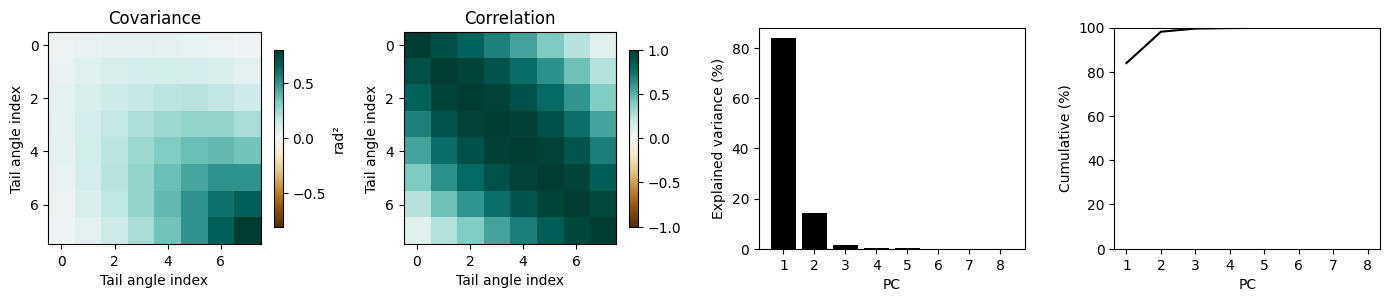

In [8]:
X_all = bout_angles.reshape(-1, n_angles)
X_all -= X_all.mean(axis=0)

# fill these lines --------------------------------------------------------------------------------
cov  = np.cov(X_all, rowvar=False)
corr = np.corrcoef(X_all, rowvar=False)

pca     = PCA(n_components=n_angles)
pca.fit(X_all)
exp_var = pca.explained_variance_ratio_

# uncomment ---------------------------------------------------------------------------------------

comps   = np.arange(1, n_angles + 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

im0 = axes[0].imshow(cov, cmap='BrBG', vmin=-np.abs(cov).max(), vmax=np.abs(cov).max())
axes[0].set_xlabel('Tail angle index')
axes[0].set_ylabel('Tail angle index')
axes[0].set_title('Covariance')
fig.colorbar(im0, ax=axes[0], shrink=0.8, label='rad²')

im1 = axes[1].imshow(corr, cmap='BrBG', vmin=-1, vmax=1)
axes[1].set_xlabel('Tail angle index')
axes[1].set_ylabel('Tail angle index')
axes[1].set_title('Correlation')
fig.colorbar(im1, ax=axes[1], shrink=0.8)

axes[2].bar(comps, exp_var * 100, color='k')
axes[2].set_xlabel('PC')
axes[2].set_ylabel('Explained variance (%)')
axes[2].set_xticks(comps)

axes[3].plot(comps, np.cumsum(exp_var) * 100, 'k-', markersize=4)
axes[3].set_xlabel('PC')
axes[3].set_ylabel('Cumulative (%)')
axes[3].set_xticks(comps)
axes[3].set_ylim(0, 100)

fig.tight_layout()
# fig.savefig('fig_cov_corr.pdf', bbox_inches='tight')

<span style="color:green">**Task**: Visualize the decomposition of the covariance into $\lambda_1 u_1 u_1^T$, $\lambda_2 u_2 u_2^T$, etc. What type covariance structure do the different principle components capture?</span>

In [ ]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# fill this line --------------------------------------------------------------------------------

cov_pc = ...

# uncomment ---------------------------------------------------------------------------------------

# titles = [r'$\Sigma$',
#           r'$\hat{\Sigma}_1 = \lambda_1\,\mathbf{u}_1\mathbf{u}_1^\top$',
#           r'$\hat{\Sigma}_2 = \lambda_2\,\mathbf{u}_2\mathbf{u}_2^\top$',
#           r'$\hat{\Sigma}_3 = \lambda_3\,\mathbf{u}_3\mathbf{u}_3^\top$']

# fig = plt.figure(figsize=(16, 7))
# outer = GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.45)

# top_axes, cbar_axes, load_axes = [], [], []
# for col in range(4):
#     inner = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0, col],
#                                     width_ratios=[10, 1], wspace=0.05)
#     top_axes.append(fig.add_subplot(inner[0]))
#     cbar_axes.append(fig.add_subplot(inner[1]))
#     if col > 0:
#         inner_bot = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1, col],
#                                             width_ratios=[10, 1], wspace=0.05)
#         load_axes.append(fig.add_subplot(inner_bot[0]))
#         fig.add_subplot(inner_bot[1]).set_visible(False)

# for ax, cax, mat, title in zip(top_axes, cbar_axes, [cov] + cov_pc, titles):
#     vlim = np.abs(mat).max()
#     im = ax.imshow(mat, cmap='BrBG', vmin=-vlim, vmax=vlim)
#     ax.set_xlabel('Tail angle index')
#     ax.set_ylabel('Tail angle index')
#     ax.set_title(title)
#     fig.colorbar(im, cax=cax)

# top_axes[0].get_figure().add_subplot(outer[1, 0]).set_visible(False)

# segs = np.arange(n_angles)
# for k, ax in enumerate(load_axes):
#     ax.bar(segs, pca.components_[k], color='k')
#     ax.axhline(0, color='k', linewidth=0.5)
#     ax.set_xlabel('Tail angle index')
#     ax.set_ylabel(rf'$\mathbf{{u}}_{k+1}$')
#     ax.set_xticks(segs)

# fig.savefig('fig_cov_reconstruction.pdf', bbox_inches='tight')

**Interpretation:** PC 1 captures correlated movement across the tail that has the highest amplitude in the tail end, while PC 2 captures anticorrelated *body-vs-tail* movement (middle vs. rear segments), PC3 goes into yet finer segment contrasts.

### 1.2  Decomposing and reconstrucing activity with PCA

Because PCA is a linear decomposition, the full angle vector at each frame can be written as a **sum of rank-1 contributions**:

$$\mathbf{x}_t \approx \tilde{U}\mathbf{z}_t = \sum_{k=1}^K z_k(t)\,\mathbf{u}_k$$

Each term $z_k(t)\,\mathbf{u}_k$ is a fixed spatial profile $\mathbf{u}_k$ multiplied by a scalar time course $z_k(t)$.

<span style="color:green">**Task**: Plot the reconstruction of the original angle time series from the first PC, as well as from the second PC. Finally, add the two up. Does the reconstructed signal look like the original data?</span>

In [ ]:
example_types = [9, 4]  # Routine Turn, Short Latency Capture Swim

bouts_ex, zs_ex, hats_pc1, hats_pc2 = [], [], [], []

# fill these lines --------------------------------------------------------------------------------

# for syl in example_types:
#     b = bout_angles[np.where(bout_labels == syl)[0][2]]
#     z = ...
#     bouts_ex.append(...)
#     zs_ex.append(...)
#     hats_pc1.append(...)
#     hats_pc2.append(...)

# uncomment ---------------------------------------------------------------------------------------

# t = np.arange(T)

# fig = plt.figure(figsize=(18, 11))
# gs = GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.35)

# for col, (syl, b, z, r1, r2) in enumerate(zip(example_types, bouts_ex, zs_ex, hats_pc1, hats_pc2)):
#     c   = col * 2
#     r12 = r1 + r2   # 2-PC reconstruction

#     ax_orig = fig.add_subplot(gs[0, c + 1])
#     ax_z1   = fig.add_subplot(gs[1, c])
#     ax_r1   = fig.add_subplot(gs[1, c + 1])
#     ax_z2   = fig.add_subplot(gs[2, c])
#     ax_r2   = fig.add_subplot(gs[2, c + 1])
#     ax_r12  = fig.add_subplot(gs[3, c + 1])

#     for j in range(n_angles):
#         ax_orig.plot(t, b[:, j], color=angle_colors[j])
#     ax_orig.set_xlabel('Frame')
#     ax_orig.set_ylabel('Tail angle (rad)')
#     ax_orig.set_title(f'Original — {bout_type_names[syl]}')

#     ax_z1.plot(t, z[:, 0], 'k')
#     ax_z1.set_xlabel('Frame')
#     ax_z1.set_ylabel('Score')
#     ax_z1.set_title('PC1 score')

#     for j in range(n_angles):
#         ax_r1.plot(t, r1[:, j], color=angle_colors[j])
#     ax_r1.set_xlabel('Frame')
#     ax_r1.set_ylabel('Tail angle (rad)')
#     ax_r1.set_title(r'$\hat{\mathbf{x}} = z_1\,\mathbf{u}_1$')

#     ax_z2.plot(t, z[:, 1], 'k')
#     ax_z2.set_xlabel('Frame')
#     ax_z2.set_ylabel('Score')
#     ax_z2.set_title('PC2 score')

#     for j in range(n_angles):
#         ax_r2.plot(t, r2[:, j], color=angle_colors[j])
#     ax_r2.set_xlabel('Frame')
#     ax_r2.set_ylabel('Tail angle (rad)')
#     ax_r2.set_title(r'$\hat{\mathbf{x}} = z_2\,\mathbf{u}_2$')

#     for j in range(n_angles):
#         ax_r12.plot(t, b[:, j], color=angle_colors[j], alpha=0.3)
#         ax_r12.plot(t, r12[:, j], color=angle_colors[j])
#     ax_r12.set_xlabel('Frame')
#     ax_r12.set_ylabel('Tail angle (rad)')
#     ax_r12.set_title(r'$\hat{\mathbf{x}} = z_1\mathbf{u}_1 + z_2\mathbf{u}_2$')

# fig.savefig('fig_pc_reconstruction_example.pdf', bbox_inches='tight')


### 1.3  The data manifold in a 2D space

Rather than plotting the PC scores as time series, we can view them jointly as **data points in the 2D state space**, containing one point per frame, colored by time within the bout. This reveals the *geometry* of the latent manifold: the set of states the fish actually visits.

The temporal color coding suggests that trajectories in the 2D state space evolve in a systematic fashion.

<span style="color:green">**Task**: Plot a single example trajectory on top of the point cloud. How do trajectories evolve in the latent state space?</span>

In [ ]:
# add a line to plot trajectory and uncomment all ---------------------------------------------------------

# from matplotlib.collections import LineCollection

# cmap_t = plt.cm.cubehelix

# Z_all_2d   = pca.transform(X_all)[:, :2]
# Z_bouts_2d = Z_all_2d.reshape(n_bouts, T, 2)[:, 20:, :]

# T_plot = T - 20
# t_vals = np.linspace(0, 1, T_plot)

# fig, axes = plt.subplots(2, 7, figsize=(18, 6), sharex=True, sharey=True)

# positions = [(0, j) for j in range(6)] + [(1, j) for j in range(7)]
# for (r, c), syl in zip(positions, range(1, 14)):
#     ax = axes[r, c]
#     z_type = Z_bouts_2d[bout_labels == syl]
#     z_flat = z_type.reshape(-1, 2)
#     t_flat = np.tile(t_vals, len(z_type))
#     ax.scatter(z_flat[:, 0], z_flat[:, 1], c=t_flat, cmap=cmap_t,
#                alpha=0.15, s=2, rasterized=True)
#     z_ex = z_type[2]
#     ax.set_box_aspect(1)
#     ax.set_title(f'{syl}: {bout_type_names[syl]}')

# axes[0, 6].set_visible(False)
# for ax in axes[:, 0]:
#     ax.set_ylabel('PC 2')
# for ax in axes[-1, :]:
#     ax.set_xlabel('PC 1')

# fig.tight_layout()
# fig.savefig('fig_latent_manifold2.pdf', bbox_inches='tight')

---
## Part 2: Dynamics

### 2.1  Flow fields

The manifold plots show *where* the system spends time in latent space. A **flow field** depicts its dynamics: at each point $\mathbf{z}$ in state space, where does the system go *next*?

In continuous dynamical systems, this is described by a velocity field $\dot{\mathbf{z}} = f(\mathbf{z})$. In our discrete-time data we have the one-step displacement

$$\Delta\mathbf{z}_t = \mathbf{z}_{t+1} - \mathbf{z}_t$$

and we can estimate its average value as a function of position nonparametrically: divide the PC1–PC2 plane into a grid of bins and compute, in each bin,

- **speed**: $\mathbb{E}[\|\Delta\mathbf{z}\|]$ — mean displacement magnitude (color)  
- **direction**: mean direction of $\Delta\mathbf{z}$ (arrows, normalized to unit length)

This gives a model-free picture of the local dynamics. Regions with high speed are where the state changes rapidly; arrows reveal whether the system rotates (oscillation), converges to a point (fixed point), or flows outward (unstable). Comparing flow fields across bout types lets us see at a glance how different behaviors differ in their dynamical structure.


In [ ]:
from scipy.stats import binned_statistic_2d
from scipy.ndimage import gaussian_filter
import numpy.ma as ma
from matplotlib.colors import LinearSegmentedColormap

cmap_flow = LinearSegmentedColormap.from_list(
    'cubehelix_r_trunc', plt.cm.cubehelix_r(np.linspace(0.2, 1.0, 256)))
cmap_flow.set_bad('black')

n_bins = 12
lim    = 3.5

xe_nw = np.linspace(-lim, lim, n_bins + 1)
ye_nw = np.linspace(-lim, lim, n_bins + 1)
xc_nw = 0.5 * (xe_nw[:-1] + xe_nw[1:])
yc_nw = 0.5 * (ye_nw[:-1] + ye_nw[1:])

def nan_smooth(arr, sigma=1):
    num = gaussian_filter(np.where(np.isnan(arr), 0, arr), sigma=sigma)
    den = gaussian_filter(np.where(np.isnan(arr), 0, 1.0), sigma=sigma)
    return np.where(den > 0.05, num / den, np.nan)

flow_cache = {}
for syl in range(1, 14):
    z     = Z_bouts_2d[bout_labels == syl]
    z_pos = z[:, :-1, :].reshape(-1, 2)
    dz    = np.diff(z, axis=1).reshape(-1, 2)
    rng   = [[-lim, lim], [-lim, lim]]
    u, xe, ye, _ = binned_statistic_2d(z_pos[:,0], z_pos[:,1], dz[:,0],
                                        statistic='mean', bins=n_bins, range=rng)
    v, *_        = binned_statistic_2d(z_pos[:,0], z_pos[:,1], dz[:,1],
                                        statistic='mean', bins=n_bins, range=rng)
    spd, *_      = binned_statistic_2d(z_pos[:,0], z_pos[:,1],
                                        np.hypot(dz[:,0], dz[:,1]),
                                        statistic='mean', bins=n_bins, range=rng)
    flow_cache[syl] = dict(
        U=nan_smooth(u.T), V=nan_smooth(v.T), speed=nan_smooth(spd.T),
        xc=xc_nw, yc=yc_nw, xe=xe_nw, ye=ye_nw,
    )

vmax_flow = np.nanpercentile(
    np.concatenate([d['speed'].ravel() for d in flow_cache.values()]), 95)

fig, axes = plt.subplots(3, 5, figsize=(15, 9), sharex=True, sharey=True)

for ax, syl in zip(axes.flat, range(1, 14)):
    d  = flow_cache[syl]
    XX_f, YY_f = np.meshgrid(d['xc'], d['yc'])
    valid = ~np.isnan(d['U'])
    mag = np.hypot(d['U'], d['V'])
    mag = np.where(mag > 0, mag, 1)
    ax.set_facecolor('black')
    ax.pcolormesh(d['xe'], d['ye'], ma.masked_invalid(d['speed']),
                  cmap=cmap_flow, shading='flat', vmin=0, vmax=vmax_flow)
    ax.quiver(XX_f[valid], YY_f[valid], d['U'][valid]/mag[valid], d['V'][valid]/mag[valid],
              color='white', alpha=0.9)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_box_aspect(1)
    ax.set_title(f'{syl}: {bout_type_names[syl]}')

for ax in axes.flat[13:]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel('PC 2')
for ax in axes[-1, :]:
    ax.set_xlabel('PC 1')

fig.tight_layout()
# fig.savefig('fig_flow_fields.pdf', bbox_inches='tight')


### 2.2  Linear Dynamical Systems (LDS)

A **Linear Dynamical System (LDS)** models how a low-dimensional latent state $\mathbf{z}_t$ evolves over time and generates high-dimensional observations $\mathbf{x}_t$:

$$\mathbf{z}_t = A\,\mathbf{z}_{t-1} + \mathbf{b}_t, \quad \mathbf{b}_t \sim \mathcal{N}(\mathbf{0},\, Q)$$
$$\mathbf{x}_t = C\,\mathbf{z}_t + \mathbf{d}_t, \quad \mathbf{d}_t \sim \mathcal{N}(\mathbf{0},\, R)$$

The top equation is an **autoregressive (AR(1)) model**, describing how the latent state $\mathbf{z}_t$ evolves linearly as a function of the $d\times d$ dynamics matrix $A$. The bottom equation is the **observation model**: the high-dimensional observations $\mathbf{x}_t$ are a noisy linear readout of the latent state via the emission matrix $C$.

Jointly estimating $A$ and $C$ from raw observations requires iterative methods such as the EM algorithm. Here we take a simpler **two-step approach** that leverages the PCA we already fitted:

1. **Fix $C$ to the PCA loadings.** We treat the pre-fitted PC projection as our observation model, mapping 8D tail angles to a 2D latent space.
2. **Fit $A$ by OLS** on the 2D PCA trajectories — this is the closed-form MLE solution for linear dynamics, given the latent states.

Written out component-wise, the transition equation for our 2D latent space is:

$$\begin{pmatrix} z_1(t) \\ z_2(t) \end{pmatrix} = \begin{pmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{pmatrix} \begin{pmatrix} z_1(t-1) \\ z_2(t-1) \end{pmatrix} + \begin{pmatrix} b_1(t) \\ b_2(t) \end{pmatrix}$$

The four entries of $A$ fully characterize the deterministic part of the latent dynamics:

- **Diagonal elements** ($a_{11}, a_{22}$): how strongly each dimension feeds back on itself. A value near 1 means slow decay (persistent state); near 0 means fast return to the origin; negative values produce frame-to-frame sign alternation.
- **Off-diagonal elements** ($a_{12}, a_{21}$): coupling between the two PC dimensions. Non-zero off-diagonal entries allow the state to *rotate* in the PC1–PC2 plane — which is precisely what produces oscillatory dynamics.

<span style="color:green">**Task**: Write a function that fits an autoregressive model to the two-dimensional latent timeseries for each bout. Does the model give a good fit of the dynamics? Plot 1) true and predicted angle time series, 2) true and predicted latent variables for an example bout of each bout type.</span>

In [ ]:
# Shared variables for dynamics fitting
Z_all        = pca.transform(X_all)[:, :2]          # (n_bouts*T, 2)
Z_bouts_all  = Z_all.reshape(n_bouts, T, 2)         # (n_bouts, T, 2)
labels_frames = np.repeat(bout_labels, T)            # frame-level labels
z_bout        = Z_bouts_all[np.where(bout_labels == 9)[0][2]]  # example: Routine Turn

In [ ]:
# fill this line --------------------------------------------------------------------------------

# def fit_ar1(z):
#     """OLS fit of A in z_t = A z_{t-1} + noise. z shape: (T, d)."""
#     return ...

In [ ]:
# Fit AR(1) per bout type using all frames of that type
A_per_type = {}
for syl in np.unique(bout_labels):
    z_syl = Z_all[labels_frames == syl]
    if len(z_syl) >= 10:
        A = fit_ar1(z_syl)
        A_per_type[syl] = A

<span style="color:green">**Task**: Plot the dynamics matrices for each syllable and analyze its eigenvalues. Which type of dynamics do bouts show?</span>

In [ ]:
# Dynamics matrices A_k per bout type
vlim = max(np.abs(A).max() for A in A_per_type.values())

fig, axes = plt.subplots(2, 7, figsize=(18, 6))

positions = [(0, j) for j in range(6)] + [(1, j) for j in range(7)]
for (r, c), syl in zip(positions, range(1, 14)):
    ax = axes[r, c]
    if syl not in A_per_type:
        ax.set_visible(False)
        continue
    A  = A_per_type[syl]
    im = ax.imshow(A, cmap='BrBG', vmin=-vlim, vmax=vlim)
    ax.set_title(f'{syl}: {bout_type_names[syl]}')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['z1', 'z2'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['z1', 'z2'])
    for ri in range(2):
        for ci in range(2):
            ax.text(ci, ri, f'{A[ri,ci]:.2f}', ha='center', va='center', fontsize=8)

axes[0, 6].set_visible(True)
axes[0, 6].axis('off')
fig.colorbar(im, ax=axes[0, 6], shrink=0.8, label='Weight')
fig.tight_layout()
# fig.savefig('fig_dynamics_matrices.pdf', bbox_inches='tight')


In [ ]:
# Eigenvalue spectrum per bout type
eig_per_type = {syl: np.linalg.eigvals(A_per_type[syl]) for syl in A_per_type}

fig, (ax, ax_leg) = plt.subplots(1, 2, figsize=(6, 3),
                                   gridspec_kw={'width_ratios': [1, 0.55]})
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8, alpha=0.5)

for syl, eigvals in eig_per_type.items():
    for lam in eigvals:
        ax.scatter(lam.real, lam.imag, color=bout_colors[syl-1], s=60, zorder=3)

ax.set_xlabel('Re(λ)')
ax.set_ylabel('Im(λ)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_aspect('equal')

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=bout_colors[syl-1], markersize=7,
           label=f'{syl}: {bout_type_names[syl]}') for syl in A_per_type]
ax_leg.legend(handles=handles, fontsize=7, loc='center left', frameon=False)
ax_leg.axis('off')

fig.tight_layout()
# fig.savefig('fig_eigenvalues_per_type.pdf', bbox_inches='tight')


**Reading eigenvalue plots.** The eigenvalues of $A$ reveal the qualitative dynamics of each bout type. Points on the unit circle (dashed) correspond to sustained oscillations; points inside it to damped motion; complex conjugate pairs indicate rotation in state space.

| Eigenvalue $\lambda$ | Behavior |
|---|---|
| $\vert\lambda\vert < 1$, real | convergence to origin (stable fixed point) |
| $\vert\lambda\vert > 1$, real | divergence (unstable) |
| $\lambda = a \pm bi$ complex, $\vert\lambda\vert < 1$ | damped oscillation at frequency $\arg(\lambda)/(2\pi)$ |
| $\lambda$ complex, $\vert\lambda\vert \approx 1$ | sustained oscillation |

Most bout types sit just inside the unit circle with a non-zero imaginary part — consistent with the decaying oscillatory loops visible in the flow fields above.

### 2.3 Empirical vs. fitted flows

We now visualise the fitted $A_k$ for each bout type and inspect their eigenvalues. Do different bouts spiral, oscillate, or converge differently?

In [ ]:
# shared grid with empirical panels
xc18, yc18 = flow_cache[1]['xc'], flow_cache[1]['yc']
xe18, ye18 = flow_cache[1]['xe'], flow_cache[1]['ye']
XX_18, YY_18 = np.meshgrid(xc18, yc18)
Z_18 = np.stack([XX_18.ravel(), YY_18.ravel()], axis=1)

# shared colorscale across empirical and LDS panels
speeds_lds18 = []
for syl in range(1, 14):
    dZ = Z_18 @ (A_per_type[syl] - np.eye(2)).T
    speeds_lds18.append(np.hypot(dZ[:, 0], dZ[:, 1]))
emp_speeds = np.concatenate([d['speed'].ravel() for d in flow_cache.values()])
vmax_18 = np.nanpercentile(np.concatenate([emp_speeds,
                            np.concatenate(speeds_lds18)]), 95)

fig, axes = plt.subplots(13, 2, figsize=(6, 35), sharex=True, sharey=True)

for row, syl in enumerate(range(1, 14)):
    # ── left: empirical ───────────────────────────────────────────────────
    ax = axes[row, 0]
    d  = flow_cache[syl]
    XX_f, YY_f = np.meshgrid(d['xc'], d['yc'])
    valid = ~np.isnan(d['U'])
    mag_e = np.hypot(d['U'], d['V'])
    mag_e = np.where(mag_e > 0, mag_e, 1)
    ax.set_facecolor('black')
    ax.pcolormesh(d['xe'], d['ye'], ma.masked_invalid(d['speed']),
                  cmap=cmap_flow, shading='flat', vmin=0, vmax=vmax_18)
    ax.quiver(XX_f[valid], YY_f[valid], d['U'][valid]/mag_e[valid],
              d['V'][valid]/mag_e[valid], color='white', alpha=0.9)
    ax.set_ylabel(f'{syl}: {bout_type_names[syl]}', fontsize=8)

    # ── right: LDS analytical ─────────────────────────────────────────────
    ax = axes[row, 1]
    dZ  = Z_18 @ (A_per_type[syl] - np.eye(2)).T
    U   = dZ[:, 0].reshape(n_bins, n_bins)
    V   = dZ[:, 1].reshape(n_bins, n_bins)
    mag_l = np.hypot(U, V)
    mag_l = np.where(mag_l > 0, mag_l, 1)
    ax.set_facecolor('black')
    ax.pcolormesh(xe18, ye18, speeds_lds18[syl - 1].reshape(n_bins, n_bins),
                  cmap=cmap_flow, shading='flat', vmin=0, vmax=vmax_18)
    ax.quiver(XX_18, YY_18, U/mag_l, V/mag_l, color='white', alpha=0.9)

    for ax in axes[row, :]:
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_box_aspect(1)

axes[0, 0].set_title('Empirical')
axes[0, 1].set_title('LDS')
for ax in axes[-1, :]:
    ax.set_xlabel('PC 1')
fig.tight_layout()
# fig.savefig('fig_lds_flow_comparison.pdf', bbox_inches='tight')


---
## Part 3: Time-varying dynamics

### 3.1 Simulating synthetic zebrafish data

So far we have fitted one AR(1) model per bout type. Let's now simulate a synthetic zebrafish dataset from the fitted dynamics.

<span style="color:green">**Task**: Simulate a continuous time series of 200 bout labels, where each bout has 150 time frames. Between consecutive bouts, insert a rest interval of duration $\tau \sim \mathrm{Geom}(p)$ (with mean $\bar{\tau} = 200$).</span>

In [ ]:
rng       = np.random.default_rng(0)
# rest_mean = ...   # mean rest duration (frames), geometric distribution
# T_bout    = ...
# syl_seq   = ...

# rest_lens = [int(rng.geometric(1 / rest_mean)) for _ in syl_seq]

# label_gen = []
# for rest_len, syl in zip(rest_lens, syl_seq):
#     label_gen.extend([0] * rest_len)
#     label_gen.extend([syl] * T_bout)
# label_gen = np.array(label_gen)
# print(f'Total frames: {len(label_gen)}  |  Bouts: {len(syl_seq)}')

<span style="color:green">**Task**: Simulate the dynamics of the latent state using state-specific dynamics matrices that we fitted above. Initialize at a random point of the state space, making sure to not start too close to zero. During rest periods, the fish stay immobile.</span>

In [ ]:
sigma_noise = 0.001

pca_gen = []
# for rest_len, syl in zip(rest_lens, syl_seq):
#     ...
# pca_gen = np.vstack(pca_gen)

<span style="color:green">**Task**: Project the full latent sequence back to angle space via the PCA loading matrix: $\hat{\mathbf{x}}_t = \mathbf{z}_t U^\top + \bar{\mathbf{x}}$. Plot the last tail-angle and the corresponding bout-type label sequence for the first 3000 frames of the simulation.</span>


In [ ]:
# angle_gen = ...
fps_gen   = 700             # match real recording rate so time axis is in seconds
t_gen     = np.arange(len(pca_gen)) / fps_gen
print(f'Bout types present: {sorted(set(syl_seq))}')

In [ ]:
snippet = slice(3000, min(12000, len(pca_gen)))
t_s, lbl_s, ang_s = t_gen[snippet], label_gen[snippet], angle_gen[snippet, -1]

fig, ax = plt.subplots(figsize=(12, 3))

boundaries = np.where(np.diff(lbl_s))[0] + 1
starts = np.concatenate([[0], boundaries])
ends   = np.concatenate([boundaries, [len(t_s)]])
for s, e, lbl in zip(starts, ends, lbl_s[starts]):
    if lbl > 0:
        ax.axvspan(t_s[s], t_s[min(e, len(t_s) - 1)],
                   color=bout_colors[lbl - 1], alpha=0.3, linewidth=0)
ax.plot(t_s, ang_s, 'k', linewidth=0.5)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Tail angle (rad)')

fig.tight_layout()
# fig.savefig('fig_generative_model.pdf', bbox_inches='tight')


### 3.2 Switching linear dynamical systems (sLDS)

To jointly infer syllable structure, latent variables, the equations that govern their dynamics, and the equations of the dimensionality reduction, we will fit a switching linear dynamical system to our synthetic data.

An sLDS belongs to the family of **hidden Markov models**. In HMMs, a discrete latent state $s_t \in \{1,\ldots,K\}$ follows a first-order Markov chain with transition matrix $\Pi$:

$$p(s_t \mid s_{t-1}) = \Pi_{s_{t-1},\, s_t}$$

Each state emits observations, typically assumed to be i.i.d. from a Gaussian:

$$\mathbf{x}_t \mid s_t = k \;\sim\; \mathcal{N}(\boldsymbol{\mu}_k,\, \Sigma_k)$$

The HMM recovers state transition structure as well as parameters of the Gaussian observation model.

The sLDS extends the HMM by adding a continuous latent state $\mathbf{z}_t$ that is not directly observed. The discrete state $s_t$ selects a dynamics matrix $A_{s_t}$, governing how $\mathbf{z}_t$ evolves over time. High-dimensional observations $\mathbf{x}_t$ are generated through a linear emission:

$$\mathbf{z}_t = A_{s_t}\,\mathbf{z}_{t-1} + \mathbf{b}_t, \quad \mathbf{b}_t \sim \mathcal{N}(\mathbf{0}, Q_k)$$

$$\mathbf{x}_t = C\,\mathbf{z}_t + \mathbf{d}_t, \quad \mathbf{d}_t \sim \mathcal{N}(\mathbf{0}, R)$$

The sLDS jointly infers the continuous latent trajectory and the discrete state sequence directly from the raw observations. Inference is intractable exactly and is approximated by EM.

<span style="color:green">**Task**: Fit an sLDS to the continuous tail angle timeseries. Use `SLDS` from the `ssm` toolbox and set `emissions='gaussian_orthog', 'transitions='sticky', N=8, K=14, D=2` to fit 2 continuous latents and 14 discrete states to 8 tail segment angles. Since convergence is not guaranteed, run 10 different iterations and choose the model with the highest evidence lower bound (ELBO). For the fitting call, run 10 iterations of Laplace EM.<span>

In [ ]:
n_states_syn = 14

best_elbo, slds_syn, q_slds = -np.inf, None, None
for run in range(5):
    # m = ssm.SLDS(...)
    # elbos, q = m.fit(...)
    # if elbos[-1] > best_elbo:
    #     best_elbo, slds_syn, q_slds, elbos_slds = elbos[-1], m, q, elbos
    # print(f'run {run:2d}  ELBO = {elbos[-1]:.1f}{"  *best*" if m is slds_syn else ""}')

x_slds      = q_slds.mean_continuous_states[0]
states_slds = np.argmax(q_slds.mean_discrete_states[0], axis=1)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(elbos_slds, 'k')
ax.set_xlabel('EM iteration')
ax.set_ylabel('ELBO (best run)')
fig.tight_layout()
# fig.savefig('fig_slds_elbo.pdf', bbox_inches='tight')


In [ ]:
C_true = pca.components_[:2].T
C_rec  = slds_syn.emissions.Cs[0]

U_p, _, Vt_p = np.linalg.svd(C_true.T @ C_rec)
R_align       = U_p @ Vt_p
C_rec_aligned = C_rec @ R_align.T
x_slds_aligned = x_slds @ R_align.T

segs = np.arange(n_angles)
fig, axes = plt.subplots(2, 2, figsize=(6,3))
for col, (C, title) in enumerate([(C_true, 'True $C$ (PCA loadings)'),
                                    (C_rec_aligned, 'Recovered $C$ (aligned)')]):
    for row in range(2):
        axes[row, col].bar(segs, C[:, row], color='k')
        axes[row, col].axhline(0, color='k', linewidth=0.5)
        axes[row, col].set_xticks(segs)
        axes[row, col].set_ylabel(f'Dim {row+1}')
        if row == 0: axes[row, col].set_title(title)
        if row == 1: axes[row, col].set_xlabel('Tail segment')
fig.tight_layout()
# fig.savefig('fig_slds_emission.pdf', bbox_inches='tight')

cmap_t = plt.cm.cubehelix
t_norm = np.linspace(0, 1, len(pca_gen))
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, Z, title in zip(axes, [pca_gen, x_slds_aligned],
                               ['True latent (pca_gen)', 'Recovered latent (sLDS, aligned)']):
    ax.scatter(Z[:, 0], Z[:, 1], c=t_norm, cmap=cmap_t, s=1, rasterized=True)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.set_title(title); ax.set_box_aspect(1)
fig.tight_layout()
# fig.savefig('fig_slds_latent.pdf', bbox_inches='tight')

<span style="color:green">**Task**: Run the alignment and inspect the confusion matrix. Did the sLDS correctly identify the different bout types?</span>

In [ ]:
A_rec_rot = np.array([R_align   @ slds_syn.dynamics.As[i] @ R_align.T
                      for i in range(n_states_syn)])   # (14, 2, 2)

# Identify rest state as inferred state with smallest mean latent norm
mean_norm = np.array([
    np.mean(np.linalg.norm(x_slds_aligned[states_slds == k], axis=1))
    if np.any(states_slds == k) else np.inf
    for k in range(n_states_syn)
])
rest_inf   = int(np.argmin(mean_norm))
active_inf = [k for k in range(n_states_syn) if k != rest_inf]

# Match active inferred states to true bout types 1-13 via A-matrix similarity
cost = np.array([[np.linalg.norm(A_per_type[j] - A_rec_rot[i], 'fro')
                  for i in active_inf]
                 for j in range(1, 14)])   # (13, 13): true × inferred

row_s, col_s = linear_sum_assignment(cost)

true2inf_slds = np.empty(n_states_syn, dtype=int)
inf2true_slds = np.empty(n_states_syn, dtype=int)
true2inf_slds[0]       = rest_inf
inf2true_slds[rest_inf] = 0
for r, c in zip(row_s, col_s):
    inf_k = active_inf[c]
    true2inf_slds[r + 1] = inf_k
    inf2true_slds[inf_k] = r + 1

states_slds_aligned = inf2true_slds[states_slds]
A_true_syn = np.array([np.eye(2)] + [A_per_type[k] for k in range(1, 14)])
A_rec_slds = A_rec_rot[true2inf_slds]   # (14, 2, 2), ordered by true label

state_colors_syn = ['gray'] + [bout_colors[k] for k in range(13)]
cm_slds_aligned  = confusion_matrix(label_gen, states_slds_aligned,
                                     labels=list(range(n_states_syn)))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm_slds_aligned / cm_slds_aligned.sum(axis=1, keepdims=True),
               cmap='copper', vmin=0, vmax=1)
fig.colorbar(im, ax=ax, shrink=0.7, label='Fraction of true label')
ax.set_xticks(range(n_states_syn)); ax.set_yticks(range(n_states_syn))
ax.set_xticklabels(['rest'] + [str(k) for k in range(1, 14)], fontsize=7, rotation=90)
ax.set_yticklabels(['rest'] + [str(k) for k in range(1, 14)], fontsize=7)
ax.set_xlabel('Inferred state (aligned)'); ax.set_ylabel('True label  (0 = rest)')
fig.tight_layout()
# fig.savefig('fig_slds_confusion.pdf', bbox_inches='tight')

In [ ]:
snippet = slice(3000, min(12000, len(pca_gen)))
t_s   = t_gen[snippet]
lbl_s = label_gen[snippet]
inf_s = states_slds_aligned[snippet]

fig, axes = plt.subplots(3, 1, figsize=(14, 4), sharex=True,
                          gridspec_kw={'height_ratios': [1, 2, 1]})

for ax, seq in zip([axes[0], axes[2]], [lbl_s, inf_s]):
    bnd = np.where(np.diff(seq))[0] + 1
    ss  = np.concatenate([[0], bnd])
    ee  = np.concatenate([bnd, [len(t_s)]])
    for s, e, lbl in zip(ss, ee, seq[ss]):
        ax.axvspan(t_s[s], t_s[min(e, len(t_s)-1)],
                   color='gray' if lbl == 0 else bout_colors[lbl-1],
                   alpha=0.85, linewidth=0)
    ax.set_yticks([])

axes[1].plot(t_s, angle_gen[snippet, -1], 'k', linewidth=0.5)
axes[0].set_ylabel('True state')
axes[1].set_ylabel('Tail angle (rad)')
axes[2].set_ylabel('Inferred state')
axes[2].set_xlabel('Time (s)')
fig.tight_layout()
# fig.savefig('fig_slds_syn_state_recovery.pdf', bbox_inches='tight')

In [ ]:
theta_c = np.linspace(0, 2 * np.pi, 300)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, As, title in zip(axes[:2],
                          [A_true_syn, A_rec_slds],
                          ['True', 'sLDS recovered']):
    ax.plot(np.cos(theta_c), np.sin(theta_c), 'k--', linewidth=0.8, alpha=0.5)
    for k in range(n_states_syn):
        color = [0.5, 0.5, 0.5] if k == 0 else bout_colors[k - 1]
        for lam in np.linalg.eigvals(As[k]):
            ax.scatter(lam.real, lam.imag, color=color, s=50, zorder=3)
    ax.set_xlabel('Re(λ)')
    ax.set_ylabel('Im(λ)')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(title)

diag_idx    = np.array([0, 3])
offdiag_idx = np.array([1, 2])
for ax, idx, label in zip(axes[2:],
                            [diag_idx, offdiag_idx],
                            ['diagonal $A_k$', 'off-diagonal $A_k$']):
    for k in range(n_states_syn):
        color = [0.5, 0.5, 0.5] if k == 0 else bout_colors[k - 1]
        ax.scatter(A_true_syn[k].ravel()[idx], A_rec_slds[k].ravel()[idx],
                   s=20, alpha=0.7, color=color)
    vals_t = A_true_syn.reshape(-1, 4)[:, idx].ravel()
    vals_r = A_rec_slds.reshape(-1, 4)[:, idx].ravel()
    lv = max(np.abs(vals_t).max(), np.abs(vals_r).max()) * 1.05
    ax.plot([-lv, lv], [-lv, lv], 'k--', linewidth=0.8)
    ax.set_xlabel('True')
    ax.set_ylabel('Recovered')
    ax.set_aspect('equal')
    r = np.corrcoef(vals_t, vals_r)[0, 1]
    ax.set_title(f'{label}  r = {r:.3f}')

fig.tight_layout()
# fig.savefig('fig_slds_dynamics_recovery.pdf', bbox_inches='tight')


In [ ]:
xc_g, yc_g = flow_cache[1]['xc'], flow_cache[1]['yc']
xe_g, ye_g = flow_cache[1]['xe'], flow_cache[1]['ye']
XX_g, YY_g = np.meshgrid(xc_g, yc_g)
Z_g = np.stack([XX_g.ravel(), YY_g.ravel()], axis=1)

all_speeds_slds = []
for syl in range(1, 14):
    for A in [A_per_type[syl], A_rec_slds[syl]]:
        dZ = Z_g @ (A - np.eye(2)).T
        all_speeds_slds.append(np.hypot(dZ[:, 0], dZ[:, 1]))
dZ_ex = Z_g @ (A_rec_slds[0] - np.eye(2)).T
all_speeds_slds.append(np.hypot(dZ_ex[:, 0], dZ_ex[:, 1]))
vmax_slds_cmp = np.percentile(np.concatenate(all_speeds_slds), 95)

fig, axes = plt.subplots(14, 2, figsize=(6, 38), sharex=True, sharey=True)

for row, syl in enumerate(range(1, 14)):
    for col, A in enumerate([A_per_type[syl], A_rec_slds[syl]]):
        ax = axes[row, col]
        dZ  = Z_g @ (A - np.eye(2)).T
        U   = dZ[:, 0].reshape(n_bins, n_bins)
        V   = dZ[:, 1].reshape(n_bins, n_bins)
        spd = np.hypot(U, V)
        mag = np.where(spd > 0, spd, 1)
        ax.set_facecolor('black')
        ax.pcolormesh(xe_g, ye_g, spd, cmap=cmap_flow, shading='flat',
                      vmin=0, vmax=vmax_slds_cmp)
        ax.quiver(XX_g, YY_g, U/mag, V/mag, color='white', alpha=0.9)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_box_aspect(1)
    axes[row, 0].set_ylabel(f'{syl}: {bout_type_names[syl]}', fontsize=8)

# extra row: rest state (true = identity, sLDS = A_rec_slds[0])
ax = axes[13, 0]
A_rest_true = np.eye(2)
dZ  = Z_g @ (A_rest_true - np.eye(2)).T
U   = dZ[:, 0].reshape(n_bins, n_bins); V = dZ[:, 1].reshape(n_bins, n_bins)
spd = np.hypot(U, V); mag = np.where(spd > 0, spd, 1)
ax.set_facecolor('black')
ax.pcolormesh(xe_g, ye_g, spd, cmap=cmap_flow, shading='flat', vmin=0, vmax=vmax_slds_cmp)
ax.quiver(XX_g, YY_g, U/mag, V/mag, color='white', alpha=0.9)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_box_aspect(1)
ax.set_ylabel('rest (true = identity)', fontsize=8)

ax = axes[13, 1]
dZ  = Z_g @ (A_rec_slds[0] - np.eye(2)).T
U   = dZ[:, 0].reshape(n_bins, n_bins); V = dZ[:, 1].reshape(n_bins, n_bins)
spd = np.hypot(U, V); mag = np.where(spd > 0, spd, 1)
ax.set_facecolor('black')
ax.pcolormesh(xe_g, ye_g, spd, cmap=cmap_flow, shading='flat', vmin=0, vmax=vmax_slds_cmp)
ax.quiver(XX_g, YY_g, U/mag, V/mag, color='white', alpha=0.9)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_box_aspect(1)

axes[0, 0].set_title('True')
axes[0, 1].set_title('sLDS recovered')
for ax in axes[-1, :]:
    ax.set_xlabel('PC 1')
fig.tight_layout()
# fig.savefig('fig_slds_flow_true_vs_recovered.pdf', bbox_inches='tight')


### 3.3  Reconstructing real data

The simulated time series in §3.1 used AR(1) dynamics to generate continuous latent trajectories. Here we keep the same discrete structure — same bout-type sequence `syl_seq` and the same rest-interval durations `rest_lens` — but replace each synthetic bout with a randomly drawn **real** bout of the same type from `bout_angles`.

This lets us directly compare the simulated and real angle time series under an identical temporal skeleton.

In [ ]:
rng_real   = np.random.default_rng(1)
angle_real = []
for rest_len, syl in zip(rest_lens, syl_seq):
    angle_real.append(np.zeros((rest_len, n_angles)))
    idx = rng_real.choice(np.where(bout_labels == syl)[0])
    angle_real.append(bout_angles[idx])   # (T_bout, 8)
angle_real = np.vstack(angle_real)
pca_real   = pca.transform(angle_real)[:, :2]

snippet = slice(3000, min(12000, len(angle_real)))
t_s     = np.arange(angle_real.shape[0])[snippet] / fps_gen

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
for ax, angles, label in zip(axes, [angle_gen, angle_real],
                                    ['Simulated (AR(1))', 'Real bouts']):
    boundaries = np.where(np.diff(label_gen[snippet]))[0] + 1
    starts = np.concatenate([[0], boundaries])
    ends   = np.concatenate([boundaries, [snippet.stop - snippet.start]])
    lbl_s  = label_gen[snippet]
    for s, e, lbl in zip(starts, ends, lbl_s[starts]):
        if lbl > 0:
            ax.axvspan(t_s[s], t_s[min(e, len(t_s)-1)],
                       color=bout_colors[lbl-1], alpha=0.3, linewidth=0)
    ax.plot(t_s, angles[snippet, -1], 'k', linewidth=0.5)
    ax.set_ylabel(label)
axes[-1].set_xlabel('Time (s)')
fig.tight_layout()
# fig.savefig('fig_real_vs_sim.pdf', bbox_inches='tight')

### 3.4 sLDS performance on real data

<span style="color:green">**Task**: Fit the sLDS to real data. Can you recover the true bout sequence structure?</span>

In [ ]:
# fill this cell --------------------------------------------------------------------------------

In [ ]:
C_rec_real     = slds_real.emissions.Cs[0]
U_pr, _, Vt_pr = np.linalg.svd(C_true.T @ C_rec_real)
R_real          = U_pr @ Vt_pr
C_real_aligned  = C_rec_real @ R_real.T
x_real_aligned  = x_real @ R_real.T

segs = np.arange(n_angles)
fig, axes = plt.subplots(2, 2, figsize=(6,3))
for col, (C, title) in enumerate([(C_true, 'True $C$ (PCA loadings)'),
                                    (C_real_aligned, 'Recovered $C$ (aligned)')]):
    for row in range(2):
        axes[row, col].bar(segs, C[:, row], color='k')
        axes[row, col].axhline(0, color='k', linewidth=0.5)
        axes[row, col].set_xticks(segs)
        axes[row, col].set_ylabel(f'Dim {row+1}')
        if row == 0: axes[row, col].set_title(title)
        if row == 1: axes[row, col].set_xlabel('Tail segment')
fig.tight_layout()
# fig.savefig('fig_slds_real_emission.pdf', bbox_inches='tight')

t_norm = np.linspace(0, 1, len(angle_real))
fig, axes = plt.subplots(1, 2, figsize=(6,3))
for ax, Z, title in zip(axes, [pca_real, x_real_aligned],
                               ['True latent (pca_real)', 'Recovered latent (sLDS, aligned)']):
    ax.scatter(Z[:, 0], Z[:, 1], c=t_norm, cmap=cmap_t, s=1, rasterized=True)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.set_title(title); ax.set_box_aspect(1)
fig.tight_layout()
# fig.savefig('fig_slds_real_latent.pdf', bbox_inches='tight')

<span style="color:green">**Task**: Run the alignment and inspect the confusion matrix. Did the sLDS correctly identify the different bout types in the real data?</span>

In [ ]:
A_rec_rot_real = np.array([R_real @ slds_real.dynamics.As[i] @ R_real.T
                           for i in range(n_states_syn)])

mean_norm_real = np.array([
    np.mean(np.linalg.norm(x_real_aligned[states_real == k], axis=1))
    if np.any(states_real == k) else np.inf
    for k in range(n_states_syn)
])
rest_inf_real   = int(np.argmin(mean_norm_real))
active_inf_real = [k for k in range(n_states_syn) if k != rest_inf_real]

cost_real = np.array([[np.linalg.norm(A_per_type[j] - A_rec_rot_real[i], 'fro')
                       for i in active_inf_real]
                      for j in range(1, 14)])

row_r, col_r = linear_sum_assignment(cost_real)

true2inf_real = np.empty(n_states_syn, dtype=int)
inf2true_real = np.empty(n_states_syn, dtype=int)
true2inf_real[0]              = rest_inf_real
inf2true_real[rest_inf_real]  = 0
for r, c in zip(row_r, col_r):
    inf_k = active_inf_real[c]
    true2inf_real[r + 1] = inf_k
    inf2true_real[inf_k] = r + 1

states_real_aligned = inf2true_real[states_real]
A_rec_real          = A_rec_rot_real[true2inf_real]

cm_real_aligned = confusion_matrix(label_gen, states_real_aligned,
                                    labels=list(range(n_states_syn)))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm_real_aligned / cm_real_aligned.sum(axis=1, keepdims=True),
               cmap='copper', vmin=0, vmax=1)
fig.colorbar(im, ax=ax, shrink=0.7, label='Fraction of true label')
ax.set_xticks(range(n_states_syn)); ax.set_yticks(range(n_states_syn))
ax.set_xticklabels(['rest'] + [str(k) for k in range(1, 14)], fontsize=7, rotation=90)
ax.set_yticklabels(['rest'] + [str(k) for k in range(1, 14)], fontsize=7)
ax.set_xlabel('Inferred state (aligned)'); ax.set_ylabel('True label  (0 = rest)')
fig.tight_layout()
# fig.savefig('fig_slds_real_confusion.pdf', bbox_inches='tight')

In [ ]:
snippet = slice(3000, min(12000, len(angle_real)))
t_s   = np.arange(len(angle_real))[snippet] / fps_gen
lbl_s = label_gen[snippet]
inf_s = states_real_aligned[snippet]

fig, axes = plt.subplots(3, 1, figsize=(14, 4), sharex=True,
                          gridspec_kw={'height_ratios': [1, 2, 1]})

for ax, seq in zip([axes[0], axes[2]], [lbl_s, inf_s]):
    bnd = np.where(np.diff(seq))[0] + 1
    ss  = np.concatenate([[0], bnd])
    ee  = np.concatenate([bnd, [len(t_s)]])
    for s, e, lbl in zip(ss, ee, seq[ss]):
        ax.axvspan(t_s[s], t_s[min(e, len(t_s)-1)],
                   color='gray' if lbl == 0 else bout_colors[lbl-1],
                   alpha=0.85, linewidth=0)
    ax.set_yticks([])

axes[1].plot(t_s, angle_real[snippet, -1], 'k', linewidth=0.5)
axes[0].set_ylabel('True state')
axes[1].set_ylabel('Tail angle (rad)')
axes[2].set_ylabel('Inferred state')
axes[2].set_xlabel('Time (s)')
fig.tight_layout()
# fig.savefig('fig_slds_real_state_recovery.pdf', bbox_inches='tight')

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, As, title in zip(axes[:2],
                          [A_true_syn, A_rec_real],
                          ['True', 'sLDS recovered (real data)']):
    ax.plot(np.cos(theta_c), np.sin(theta_c), 'k--', linewidth=0.8, alpha=0.5)
    for k in range(n_states_syn):
        color = [0.5, 0.5, 0.5] if k == 0 else bout_colors[k - 1]
        for lam in np.linalg.eigvals(As[k]):
            ax.scatter(lam.real, lam.imag, color=color, s=50, zorder=3)
    ax.set_xlabel('Re(λ)')
    ax.set_ylabel('Im(λ)')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(title)

for ax, idx, label in zip(axes[2:],
                            [diag_idx, offdiag_idx],
                            ['diagonal $A_k$', 'off-diagonal $A_k$']):
    for k in range(n_states_syn):
        color = [0.5, 0.5, 0.5] if k == 0 else bout_colors[k - 1]
        ax.scatter(A_true_syn[k].ravel()[idx], A_rec_real[k].ravel()[idx],
                   s=20, alpha=0.7, color=color)
    vals_t = A_true_syn.reshape(-1, 4)[:, idx].ravel()
    vals_r = A_rec_real.reshape(-1, 4)[:, idx].ravel()
    lv = max(np.abs(vals_t).max(), np.abs(vals_r).max()) * 1.05
    ax.plot([-lv, lv], [-lv, lv], 'k--', linewidth=0.8)
    ax.set_xlabel('True')
    ax.set_ylabel('Recovered')
    ax.set_aspect('equal')
    r = np.corrcoef(vals_t, vals_r)[0, 1]
    ax.set_title(f'{label}  r = {r:.3f}')

fig.tight_layout()
# fig.savefig('fig_slds_real_dynamics_recovery.pdf', bbox_inches='tight')

In [ ]:
all_speeds_real = []
for syl in range(1, 14):
    for A in [A_per_type[syl], A_rec_real[syl]]:
        dZ = Z_g @ (A - np.eye(2)).T
        all_speeds_real.append(np.hypot(dZ[:, 0], dZ[:, 1]))
dZ_ex = Z_g @ (A_rec_real[0] - np.eye(2)).T
all_speeds_real.append(np.hypot(dZ_ex[:, 0], dZ_ex[:, 1]))
vmax_real_cmp = np.percentile(np.concatenate(all_speeds_real), 95)

fig, axes = plt.subplots(14, 2, figsize=(6, 38), sharex=True, sharey=True)

for row, syl in enumerate(range(1, 14)):
    for col, A in enumerate([A_per_type[syl], A_rec_real[syl]]):
        ax = axes[row, col]
        dZ  = Z_g @ (A - np.eye(2)).T
        U   = dZ[:, 0].reshape(n_bins, n_bins)
        V   = dZ[:, 1].reshape(n_bins, n_bins)
        spd = np.hypot(U, V)
        mag = np.where(spd > 0, spd, 1)
        ax.set_facecolor('black')
        ax.pcolormesh(xe_g, ye_g, spd, cmap=cmap_flow, shading='flat',
                      vmin=0, vmax=vmax_real_cmp)
        ax.quiver(XX_g, YY_g, U/mag, V/mag, color='white', alpha=0.9)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_box_aspect(1)
    axes[row, 0].set_ylabel(f'{syl}: {bout_type_names[syl]}', fontsize=8)

ax = axes[13, 0]
dZ  = Z_g @ (A_rest_true - np.eye(2)).T
U   = dZ[:, 0].reshape(n_bins, n_bins); V = dZ[:, 1].reshape(n_bins, n_bins)
spd = np.hypot(U, V); mag = np.where(spd > 0, spd, 1)
ax.set_facecolor('black')
ax.pcolormesh(xe_g, ye_g, spd, cmap=cmap_flow, shading='flat', vmin=0, vmax=vmax_real_cmp)
ax.quiver(XX_g, YY_g, U/mag, V/mag, color='white', alpha=0.9)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_box_aspect(1)
ax.set_ylabel('rest (true = identity)', fontsize=8)

ax = axes[13, 1]
dZ  = Z_g @ (A_rec_real[0] - np.eye(2)).T
U   = dZ[:, 0].reshape(n_bins, n_bins); V = dZ[:, 1].reshape(n_bins, n_bins)
spd = np.hypot(U, V); mag = np.where(spd > 0, spd, 1)
ax.set_facecolor('black')
ax.pcolormesh(xe_g, ye_g, spd, cmap=cmap_flow, shading='flat', vmin=0, vmax=vmax_real_cmp)
ax.quiver(XX_g, YY_g, U/mag, V/mag, color='white', alpha=0.9)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_box_aspect(1)

axes[0, 0].set_title('True')
axes[0, 1].set_title('sLDS recovered (real data)')
for ax in axes[-1, :]:
    ax.set_xlabel('PC 1')
fig.tight_layout()
# fig.savefig('fig_slds_real_flow.pdf', bbox_inches='tight')

### Summary

| Concept | Where introduced | Key takeaway |
|---|---|---|
| Covariance matrix | §1.3 | Correlated movements create structure that PCA can exploit |
| PCA / latent space | §1.3–1.4 | High-D posture data lives on a 2-D manifold |
| Oscillatory dynamics | §1.5–1.6 | Same oscillation visible in both observation and latent space |
| AR(1) / LDS | §1.7–1.8 | $\mathbf{z}_t = A \mathbf{z}_{t-1}$; complex eigenvalues → oscillation |
| Time-varying dynamics | §2.6 | AR-HMM infers discrete states each with their own linear dynamics |
| Switching LDS (AR-HMM) | §2.6–2.7 | Jointly infers discrete states and per-state linear dynamics |

---
### Bonus: forward rollout vs one-step prediction

The one-step prediction $\hat{\mathbf{z}}_t = A\,\mathbf{z}_{t-1}$ is corrected every frame by the true state. A stricter test is a **free rollout**: starting from frame 18, apply $A$ repeatedly without any correction. Good dynamics capture means the rollout stays close to the true trajectory for many frames.

In [ ]:
roll_start = 30
t_full = np.arange(T)
t_pred = np.arange(T - 1)

fig, axes = plt.subplots(13, 4, figsize=(14, 32), sharey='col')

for row, syl in enumerate(range(1, 14)):
    idx        = np.where(bout_labels == syl)[0][2]
    b_syl      = bout_angles[idx]
    z_syl      = Z_bouts_all[idx]
    A_syl      = A_per_type.get(syl)
    if A_syl is None:
        for ax in axes[row]: ax.set_visible(False)
        continue

    z_pred_syl = z_syl[:-1] @ A_syl.T
    x_pred_syl = z_pred_syl @ pca.components_[:2]

    n_roll    = T - roll_start
    z_roll    = np.zeros((n_roll, 2))
    z_roll[0] = z_syl[roll_start]
    for k in range(1, n_roll):
        z_roll[k] = A_syl @ z_roll[k - 1]
    t_roll = np.arange(roll_start, T)

    for j in range(n_angles):
        axes[row, 0].plot(t_full, b_syl[:, j],      color=angle_colors[j])
        axes[row, 1].plot(t_pred, x_pred_syl[:, j], color=angle_colors[j])

    for pc, ax in enumerate([axes[row, 2], axes[row, 3]]):
        ax.plot(t_full, z_syl[:, pc],      'k',                       label='true')
        ax.plot(t_pred, z_pred_syl[:, pc], 'k', alpha=0.4, dashes=[4, 2], label='1-step')
        ax.plot(t_roll, z_roll[:, pc],     color='orange', alpha=0.6,  label='rollout')

    axes[row, 0].set_ylabel(f'{syl}: {bout_type_names[syl]}', fontsize=7)

for ax in axes[-1]:
    ax.set_xlabel('Frame')
for ax, title in zip(axes[0], ['True tail angles', 'AR(1) predicted angles',
                                 'PC 1', 'PC 2']):
    ax.set_title(title, fontsize=9)
axes[0, 2].legend(fontsize=7, loc='upper right')

fig.tight_layout()
# fig.savefig('fig_ar1_rollout.pdf', bbox_inches='tight')
